In [24]:
import numpy as np
import pickle 
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import pandas as pd
import cv2

In [25]:
# Load the provided pickle file
file_path = ('results/1.pkl')
with open(file_path, 'rb') as file:
    data = pickle.load(file)

# Display the keys in the loaded data to understand its structure
data.keys()
gt_keypoints_T = data['gt']
frame_T = data['frame']

dict_keys(['right_shoulder', 'left_shoulder', 'right_elbow', 'left_elbow', 'right_wrist', 'left_wrist', 'right_hip', 'left_hip', 'right_knee', 'left_knee', 'right_ankle', 'left_ankle', 'right_heel', 'left_heel', 'right_foot_index', 'left_foot_index'])


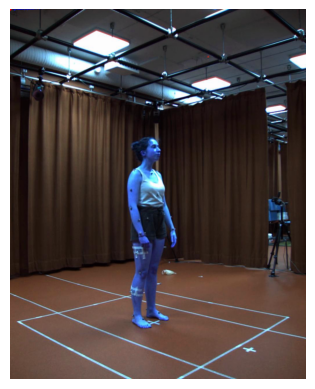

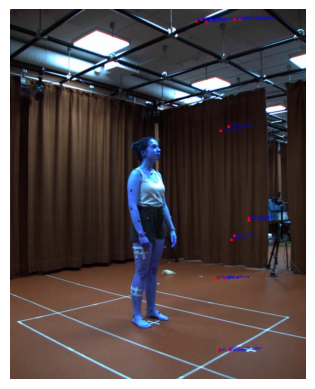

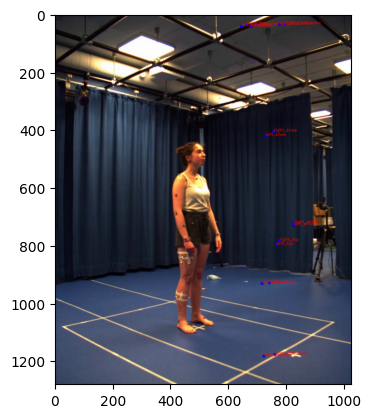

In [26]:
file_path = ('results/1.pkl')
with open(file_path, 'rb') as file:
    data = pickle.load(file)
    
data.keys()
gt_keypoints = data['pred']
frame = data['frame']   

def plot_3d_keypoints(keypoints_ground_truth, model_name, image):
    colors = ['red']
    names = ['Ground Truth KeyPoints']

    # Define connections between related keypoints
    if model_name == 'mediapipe':
        connections = [(0, 1), (0, 2), (1, 3), (2, 4), (3, 5), (6, 7), (0, 6),
                       (1, 7), (6, 8), (7, 9), (8, 10), (9, 11), (10, 12),
                       (11, 13), (10, 14), (11, 15), (12, 14), (13, 15)]

    # Create a Plotly 3D scatter plot
    fig = go.Figure()

    keypoints_dict = keypoints_ground_truth
    keypoints_array = np.array([v for v in keypoints_dict.values()])
    x, y, z = keypoints_array[:, 0], -keypoints_array[:, 1], keypoints_array[:, 2]

    # Scatter plot for keypoints
    for kp_name, kp_x, kp_y, kp_z in zip(keypoints_dict.keys(), x, y, z):
        fig.add_trace(go.Scatter3d(
            x=[kp_z], y=[kp_x], z=[kp_y], mode='markers',
            marker=dict(color=colors[0], size=5),
            text=[kp_name], textposition="top center",
            name=f'{names[0]} {kp_name}'
        ))

    # Plot connections
    for connection in connections:
        x_vals = [x[connection[0]], x[connection[1]]]
        y_vals = [y[connection[0]], y[connection[1]]]
        z_vals = [z[connection[0]], z[connection[1]]]
        fig.add_trace(go.Scatter3d(
            x=z_vals, y=x_vals, z=y_vals, mode='lines',
            line=dict(color=colors[0]),
            name=f'{names[0]} Connection {connection[0]}-{connection[1]}'
        ))

    # Combine x, y, z values into a single list
    all_values = tuple(x) + tuple(y) + tuple(z)

    # Find the minimum and maximum values
    min_value = min(all_values) - abs(min(all_values) * 0.1)
    max_value = max(all_values) + abs(max(all_values) * 0.1)

    # Update layout to set axis limits
    fig.update_layout(
        scene=dict(
            aspectmode='cube',
            xaxis=dict(title='X', range=[min_value, max_value]),
            yaxis=dict(title='Y', range=[min_value, max_value]),
            zaxis=dict(title='Z', range=[min_value, max_value])
        )
    )

    # Show the figure
    fig.show()
    
        # Overlay 2D keypoints on image if provided
    if image is not None:
        overlay_2d_keypoints_on_image(keypoints_dict, image, connections)

    
def overlay_2d_keypoints_on_image(keypoints, image, connections):
    if isinstance(next(iter(keypoints.keys())), int):
        for connection in connections:
            pt1 = (int(keypoints[connection[0]][0]), int(keypoints[connection[0]][1]))
            pt2 = (int(keypoints[connection[1]][0]), int(keypoints[connection[1]][1]))
            cv2.line(image, pt1, pt2, (0, 255, 0), 2)
    
    for kp_name, kp in keypoints.items():
        pt = (int(kp[0]), int(kp[1]))
        cv2.circle(image, pt, 5, (0, 0, 255), -1)
        cv2.putText(image, str(kp_name), pt, cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1, cv2.LINE_AA)

    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

# Check the structure of the keypoints
print(gt_keypoints.keys())


# Example usage with the gt_keypoints data
plot_3d_keypoints(data['pred'], 'mediapipe', frame)
plot_3d_keypoints(data['gt'], 'mediapipe', frame)
plt.imshow(frame)


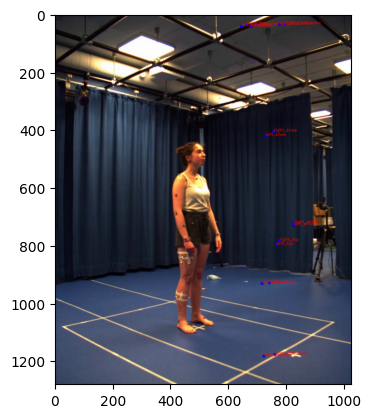

In [27]:
plt.imshow(frame)

In [28]:
def calculate_angle_point(joint_a, joint_b, joint_c):
    """
    Calculate the angle formed at joint_b by the lines connecting joint_a and joint_c
    :param joint_a: 3D coordinates of joint A, numpy array of shape [sample, joint, 3]
    :param joint_b: 3D coordinates of joint B (vertex of the angle), numpy array of shape [sample, joint, 3]
    :param joint_c: 3D coordinates of joint C, numpy array of shape [sample, joint, 3]
    :return: Angles in degrees, numpy array of shape [sample, joint]
    """
    # Check if any inputs need reshaping
    if len(joint_a.shape) == 1:
        joint_a = joint_a.reshape(-1, joint_a.shape[0], 3)
    if len(joint_b.shape) == 1:
        joint_b = joint_b.reshape(-1, joint_b.shape[0], 3)
    if len(joint_c.shape) == 1:
        joint_c = joint_c.reshape(-1, joint_c.shape[0], 3)

    v1 = joint_a - joint_b
    v2 = joint_c - joint_b
    v1_norm = v1 / np.linalg.norm(v1, axis=1, keepdims=True)
    v2_norm = v2 / np.linalg.norm(v2, axis=1, keepdims=True)
    dot_product = np.sum(v1_norm * v2_norm, axis=1)
    dot_product = np.clip(dot_product, -1.0, 1.0)  # Clip to ensure they are within the valid range for arccos [-1, 1]
    angles_rad = np.arccos(dot_product)
    angles_deg = np.degrees(angles_rad)
    return np.round(angles_deg, 2)


def orthogonal_projection(vector, normal):
    """
    Calculate the orthogonal projection of a vector onto a plane defined by a normal vector.
    :param vector: The vector to be projected, shape (batch, 3)
    :param normal: The normal vector of the plane, shape (batch, 3)
    :return: The orthogonal projection of the vector onto the plane, shape (batch, 3)
    """
    dot_product = np.einsum('ij,ij->i', vector, normal)
    normal_norm_sq = np.einsum('ij,ij->i', normal, normal)
    projection = vector - (dot_product / normal_norm_sq)[:, np.newaxis] * normal
    return projection


def get_vertical_axis_from_calibration(hip_left, hip_right, shoulder_left, shoulder_right):
    """
    Determine the vertical axis based on the positions of the hips and shoulders. Needs a relative neutral pose
    :param hip_left: numpy array of shape (3,), position of the left hip
    :param hip_right: numpy array of shape (3,), position of the right hip
    :param shoulder_left: numpy array of shape (3,), position of the left shoulder
    :param shoulder_right: numpy array of shape (3,), position of the right shoulder
    :return: normalized vertical axis vector
    """
    hip_mid = (hip_left + hip_right) / 2
    shoulder_mid = (shoulder_left + shoulder_right) / 2
    vertical_vector = shoulder_mid - hip_mid
    return vertical_vector / np.linalg.norm(vertical_vector)


def calculate_angle_vector(v1, v2):
    """
    Calculate the angle between two vectors.
    :param v1: First vector, numpy array of shape (batch, 3)
    :param v2: Second vector, numpy array of shape (batch, 3)
    :return: Angles in degrees, numpy array of shape (batch,)
    """
    # Check if v1 needs reshaping
    if len(v1.shape) == 1:
        v1 = v1.reshape(-1, 3)
    if len(v2.shape) == 1:
        v2 = v2.reshape(-1, 3)

    v1_norm = v1 / np.linalg.norm(v1, axis=1, keepdims=True)
    v2_norm = v2 / np.linalg.norm(v2, axis=1, keepdims=True)
    dot_product = np.einsum('ij,ij->i', v1_norm, v2_norm)
    dot_product = np.clip(dot_product, -1.0, 1.0)  # Clip to ensure they are within the valid range for arccos [-1, 1]
    angles_rad = np.arccos(dot_product)
    angles_deg = np.degrees(angles_rad)
    return np.round(angles_deg, 2)

def trunk_plan(u, v):
    return np.cross(u, v)


def calculate_joint_angles(keypoints, Y_vector=np.array([0, 1, 0])):
    angles = {}

    # Ensure all keypoints are reshaped to be 3D
    keypoints = {k: v.reshape(-1, 3) for k, v in keypoints.items()}

    shoulder_mid = (keypoints['right_shoulder'] + keypoints['left_shoulder']) / 2
    hip_mid = (keypoints['right_hip'] + keypoints['left_hip']) / 2

    D_s = np.cross(hip_mid - shoulder_mid, keypoints['right_shoulder'] - keypoints['left_shoulder'])
    D_h = np.cross(Y_vector, keypoints['right_hip'] - keypoints['left_hip'])

    angles['trunk_angle'] = 90 - calculate_angle_vector(hip_mid - shoulder_mid, D_h)
    angles['trunk_twist'] = 180 - calculate_angle_vector(
        orthogonal_projection(keypoints['left_hip'] - keypoints['right_hip'], shoulder_mid - hip_mid),
        orthogonal_projection(keypoints['right_shoulder'] - keypoints['left_shoulder'], shoulder_mid - hip_mid))
    angles['trunk_bend'] = calculate_angle_vector(Y_vector, orthogonal_projection(shoulder_mid - hip_mid, D_h))

    angles['knee_angle_l'] = 90 + calculate_angle_point(keypoints['left_hip'], hip_mid, keypoints['left_ankle'])
    angles['knee_angle_r'] = 90 + calculate_angle_point(keypoints['right_hip'], hip_mid, keypoints['right_ankle'])
    angles['ankle_angle_l'] = calculate_angle_point(keypoints['left_knee'], keypoints['left_ankle'], keypoints['left_foot_index'])
    angles['ankle_angle_r'] = calculate_angle_point(keypoints['right_knee'], keypoints['right_ankle'], keypoints['right_foot_index'])

    angles['shoulder_side_l'] = calculate_angle_vector(orthogonal_projection(keypoints['left_elbow'] - keypoints['left_shoulder'], np.cross(D_s, shoulder_mid - hip_mid)), shoulder_mid - hip_mid) * np.sign(np.dot(keypoints['left_elbow'] - keypoints['left_shoulder'], D_s.T))[0]
    angles['shoulder_side_r'] = calculate_angle_vector(
        orthogonal_projection(keypoints['right_elbow'] - keypoints['right_shoulder'], np.cross(D_s, shoulder_mid - hip_mid)),
        shoulder_mid - hip_mid) * np.sign(np.dot(keypoints['right_elbow'] - keypoints['right_shoulder'], D_s.T))[0]
    
    angles['elbow_angle_l'] = calculate_angle_point(keypoints['left_shoulder'], keypoints['left_elbow'], keypoints['left_wrist'])
    angles['elbow_angle_r'] = calculate_angle_point(keypoints['right_shoulder'], keypoints['right_elbow'], keypoints['right_wrist'])
    
    angles['shoulder_abduc_l'] = calculate_angle_vector( keypoints['right_elbow'] - keypoints['right_shoulder'],keypoints['right_hip'] - keypoints['right_shoulder']) 
    angles['shoulder_abduc_r'] = calculate_angle_vector( keypoints['left_elbow'] - keypoints['left_shoulder'],keypoints['left_hip'] - keypoints['left_shoulder']) 
    angles['shoulder_flex_l'] = 90 - calculate_angle_vector( keypoints['right_elbow'] - keypoints['right_shoulder'], D_s) 
    angles['shoulder_flex_r'] = 90 - calculate_angle_vector( keypoints['left_elbow'] - keypoints['left_shoulder'], D_s) 
    
    
    return angles



In [29]:
keypoints_dict = {
    'left_shoulder': gt_keypoints['left_shoulder'],
    'right_shoulder': gt_keypoints['right_shoulder'],
    'left_hip': gt_keypoints['left_hip'],
    'right_hip': gt_keypoints['right_hip'],
    'left_knee': gt_keypoints['left_knee'],
    'right_knee': gt_keypoints['right_knee'],
    'left_ankle': gt_keypoints['left_ankle'],
    'right_ankle': gt_keypoints['right_ankle'],
    'left_foot_index': gt_keypoints['left_foot_index'],
    'right_foot_index': gt_keypoints['right_foot_index'],
    'left_elbow': gt_keypoints['left_elbow'],
    'right_elbow': gt_keypoints['right_elbow'],
    'left_wrist': gt_keypoints['left_wrist'],
    'right_wrist': gt_keypoints['right_wrist']
}

angles = calculate_joint_angles(keypoints_dict)

angles_df = pd.DataFrame.from_dict(angles, orient='index', columns=['Angle (degrees)'])
pd.set_option('display.max_rows', None)
print(angles_df)


gt_keypoints = gt_keypoints_T
keypoints_dict = {
    'left_shoulder': gt_keypoints['left_shoulder'],
    'right_shoulder': gt_keypoints['right_shoulder'],
    'left_hip': gt_keypoints['left_hip'],
    'right_hip': gt_keypoints['right_hip'],
    'left_knee': gt_keypoints['left_knee'],
    'right_knee': gt_keypoints['right_knee'],
    'left_ankle': gt_keypoints['left_ankle'],
    'right_ankle': gt_keypoints['right_ankle'],
    'left_foot_index': gt_keypoints['left_foot_index'],
    'right_foot_index': gt_keypoints['right_foot_index'],
    'left_elbow': gt_keypoints['left_elbow'],
    'right_elbow': gt_keypoints['right_elbow'],
    'left_wrist': gt_keypoints['left_wrist'],
    'right_wrist': gt_keypoints['right_wrist']
}

angles = calculate_joint_angles(keypoints_dict)

angles_df = pd.DataFrame.from_dict(angles, orient='index', columns=['Angle (degrees)'])
pd.set_option('display.max_rows', None)
print(angles_df)



                  Angle (degrees)
trunk_angle                  0.56
trunk_twist                 13.42
trunk_bend                 173.14
knee_angle_l               158.66
knee_angle_r               181.94
ankle_angle_l               98.10
ankle_angle_r               76.23
shoulder_side_l           -178.27
shoulder_side_r           -167.72
elbow_angle_l              165.79
elbow_angle_r              172.48
shoulder_abduc_l            20.61
shoulder_abduc_r            16.30
shoulder_flex_l            -11.83
shoulder_flex_r             -1.69
                  Angle (degrees)
trunk_angle                  4.50
trunk_twist                  3.82
trunk_bend                   1.45
knee_angle_l               179.94
knee_angle_r               166.54
ankle_angle_l               86.15
ankle_angle_r               82.95
shoulder_side_l            174.92
shoulder_side_r            169.68
elbow_angle_l              149.68
elbow_angle_r              148.52
shoulder_abduc_l            23.80
shoulder_abduc

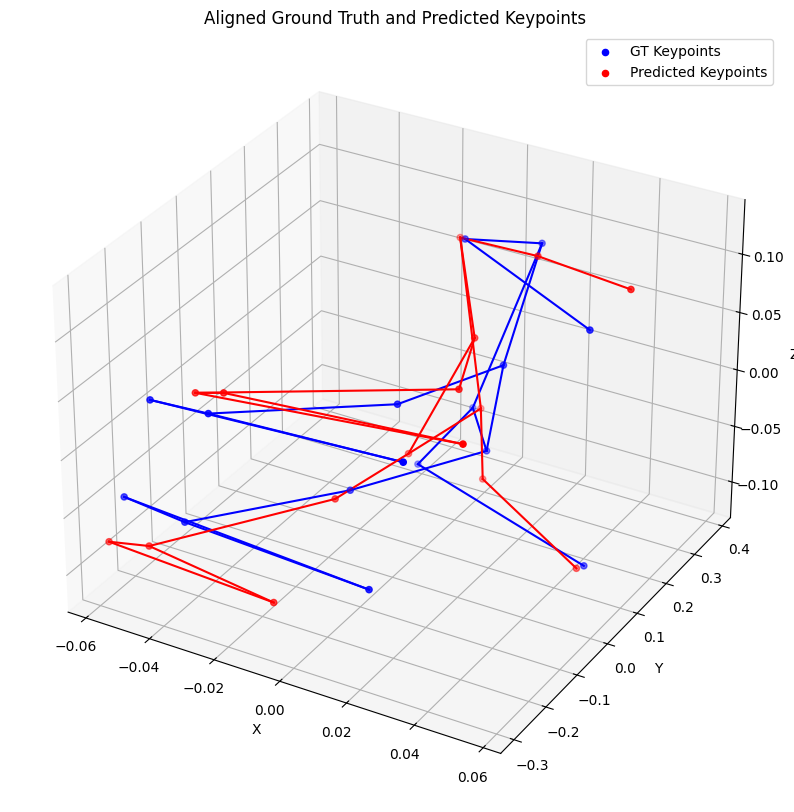

In [30]:
import pickle
import numpy as np
from scipy.spatial import procrustes
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load the dataset
file_path = 'results/1.pkl'
with open(file_path, 'rb') as file:
    data = pickle.load(file)

# Convert the keypoints dictionaries into numpy arrays for Procrustes analysis
gt_points = np.array(list(data['gt'].values()))
pred_points = np.array(list(data['pred'].values()))

# Perform Procrustes analysis for 3D coordinates
mtx1_3d, mtx2_3d, disparity_3d = procrustes(gt_points, pred_points)

# Define the connections
connections = [(0, 1), (0, 2), (1, 3), (2, 4), (3, 5), (6, 7), (0, 6),
               (1, 7), (6, 8), (7, 9), (8, 10), (9, 11), (10, 12),
               (11, 13), (10, 14), (11, 15), (12, 14), (13, 15)]

# Create an interactive 3D plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot GT keypoints
ax.scatter(mtx1_3d[:, 0], mtx1_3d[:, 1], mtx1_3d[:, 2], color='blue', label='GT Keypoints')
for start, end in connections:
    ax.plot([mtx1_3d[start, 0], mtx1_3d[end, 0]], [mtx1_3d[start, 1], mtx1_3d[end, 1]], [mtx1_3d[start, 2], mtx1_3d[end, 2]], color='blue')

# Plot predicted keypoints
ax.scatter(mtx2_3d[:, 0], mtx2_3d[:, 1], mtx2_3d[:, 2], color='red', label='Predicted Keypoints')
for start, end in connections:
    ax.plot([mtx2_3d[start, 0], mtx2_3d[end, 0]], [mtx2_3d[start, 1], mtx2_3d[end, 1]], [mtx2_3d[start, 2], mtx2_3d[end, 2]], color='red')

ax.set_title('Aligned Ground Truth and Predicted Keypoints')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()

plt.show()

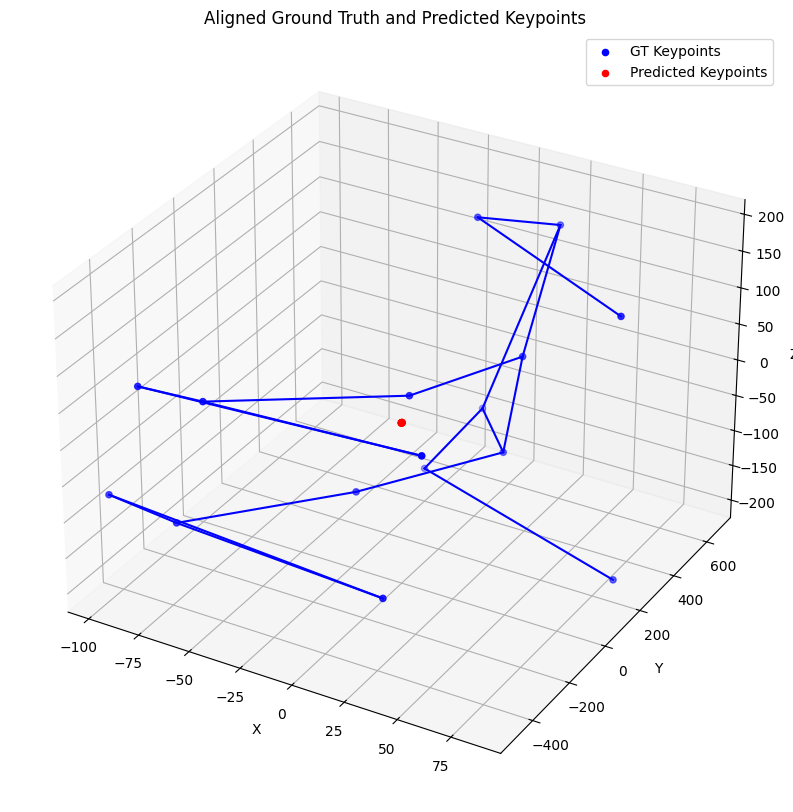

In [31]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load the dataset
file_path = 'results/1.pkl'
with open(file_path, 'rb') as file:
    data = pickle.load(file)

# Convert the keypoints dictionaries into numpy arrays
gt_points = np.array(list(data['gt'].values()))
pred_points = np.array(list(data['pred'].values()))

# Center the points
gt_centered = gt_points - np.mean(gt_points, axis=0)
pred_centered = pred_points - np.mean(pred_points, axis=0)

# Compute the covariance matrix
cov_matrix = np.dot(pred_centered.T, gt_centered)

# Singular Value Decomposition
U, S, Vt = np.linalg.svd(cov_matrix)

# Compute the rotation matrix
R = np.dot(Vt.T, U.T)

# Apply the rotation to the predicted points
pred_aligned = np.dot(pred_centered, R)

# Define the connections
connections = [(0, 1), (0, 2), (1, 3), (2, 4), (3, 5), (6, 7), (0, 6),
               (1, 7), (6, 8), (7, 9), (8, 10), (9, 11), (10, 12),
               (11, 13), (10, 14), (11, 15), (12, 14), (13, 15)]

# Create an interactive 3D plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot GT keypoints
ax.scatter(gt_centered[:, 0], gt_centered[:, 1], gt_centered[:, 2], color='blue', label='GT Keypoints')
for start, end in connections:
    ax.plot([gt_centered[start, 0], gt_centered[end, 0]], [gt_centered[start, 1], gt_centered[end, 1]], [gt_centered[start, 2], gt_centered[end, 2]], color='blue')

# Plot predicted keypoints
ax.scatter(pred_aligned[:, 0], pred_aligned[:, 1], pred_aligned[:, 2], color='red', label='Predicted Keypoints')
for start, end in connections:
    ax.plot([pred_aligned[start, 0], pred_aligned[end, 0]], [pred_aligned[start, 1], pred_aligned[end, 1]], [pred_aligned[start, 2], pred_aligned[end, 2]], color='red')

ax.set_title('Aligned Ground Truth and Predicted Keypoints')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()

plt.show()


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


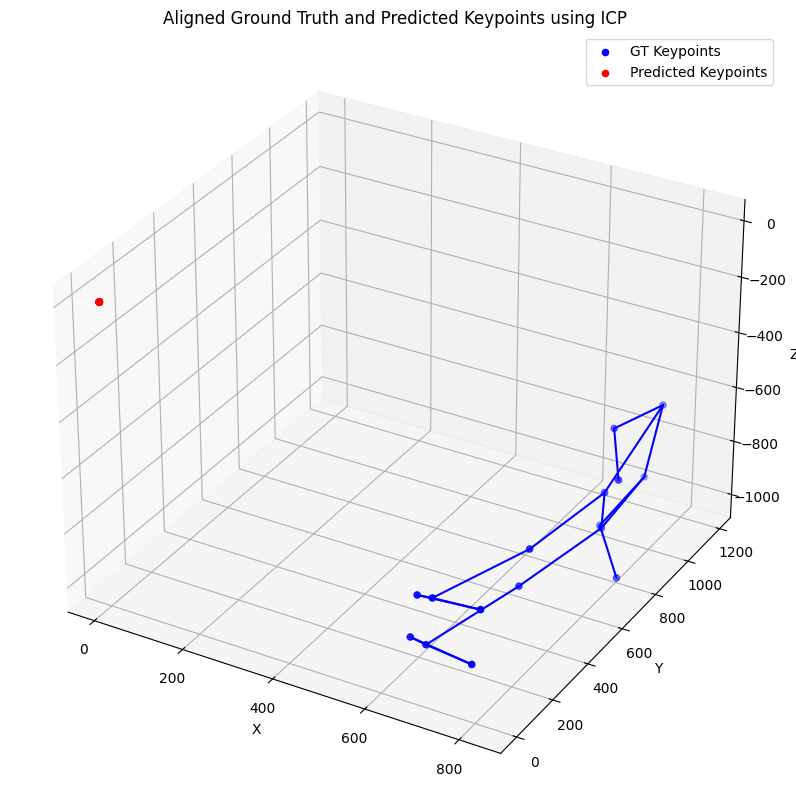

In [32]:
import pickle
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load the dataset
file_path = 'results/1.pkl'
with open(file_path, 'rb') as file:
    data = pickle.load(file)

# Convert the keypoints dictionaries into numpy arrays
gt_points = np.array(list(data['gt'].values()))
pred_points = np.array(list(data['pred'].values()))

# Create Open3D point clouds
gt_cloud = o3d.geometry.PointCloud()
pred_cloud = o3d.geometry.PointCloud()
gt_cloud.points = o3d.utility.Vector3dVector(gt_points)
pred_cloud.points = o3d.utility.Vector3dVector(pred_points)

# Perform ICP
threshold = 1.0
trans_init = np.eye(4)
reg_p2p = o3d.pipelines.registration.registration_icp(
    pred_cloud, gt_cloud, threshold, trans_init,
    o3d.pipelines.registration.TransformationEstimationPointToPoint()
)
transformation = reg_p2p.transformation

# Apply the transformation to the predicted points
pred_points_aligned = np.asarray(pred_cloud.transform(transformation).points)

# Define the connections
connections = [(0, 1), (0, 2), (1, 3), (2, 4), (3, 5), (6, 7), (0, 6),
               (1, 7), (6, 8), (7, 9), (8, 10), (9, 11), (10, 12),
               (11, 13), (10, 14), (11, 15), (12, 14), (13, 15)]

# Create an interactive 3D plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot GT keypoints
ax.scatter(gt_points[:, 0], gt_points[:, 1], gt_points[:, 2], color='blue', label='GT Keypoints')
for start, end in connections:
    ax.plot([gt_points[start, 0], gt_points[end, 0]], [gt_points[start, 1], gt_points[end, 1]], [gt_points[start, 2], gt_points[end, 2]], color='blue')

# Plot aligned predicted keypoints
ax.scatter(pred_points_aligned[:, 0], pred_points_aligned[:, 1], pred_points_aligned[:, 2], color='red', label='Predicted Keypoints')
for start, end in connections:
    ax.plot([pred_points_aligned[start, 0], pred_points_aligned[end, 0]], [pred_points_aligned[start, 1], pred_points_aligned[end, 1]], [pred_points_aligned[start, 2], pred_points_aligned[end, 2]], color='red')

ax.set_title('Aligned Ground Truth and Predicted Keypoints using ICP')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()

plt.show()


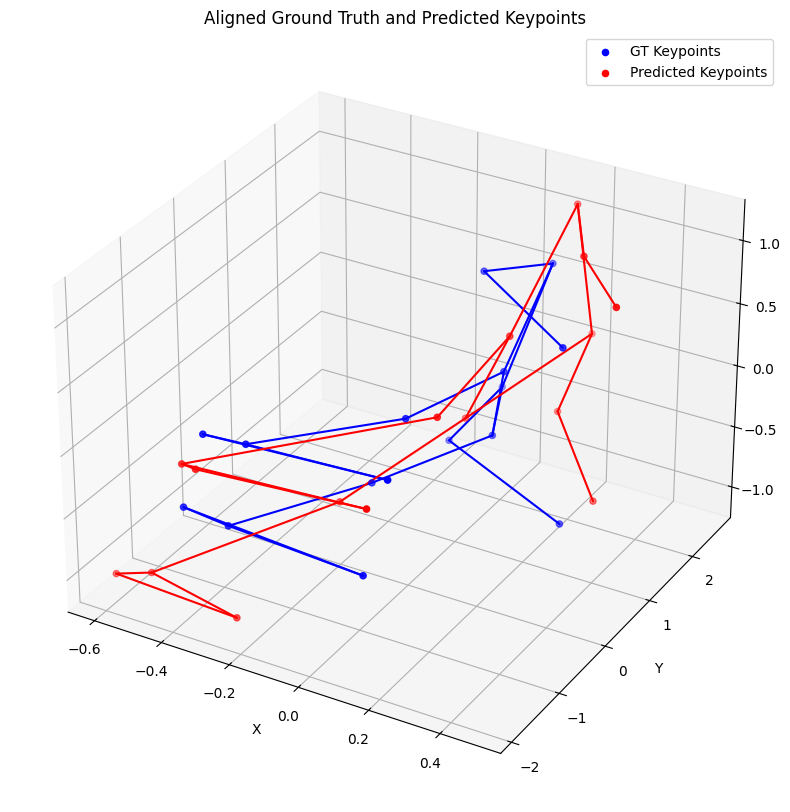

In [33]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load the dataset
file_path = 'results/1.pkl'
with open(file_path, 'rb') as file:
    data = pickle.load(file)

# Convert the keypoints dictionaries into numpy arrays
gt_points = np.array(list(data['gt'].values()))
pred_points = np.array(list(data['pred'].values()))

# Center the points by subtracting the mean
gt_centered = gt_points - np.mean(gt_points, axis=0)
pred_centered = pred_points - np.mean(pred_points, axis=0)

# Scale the points to have the same variance
gt_scaled = gt_centered / np.std(gt_centered)
pred_scaled = pred_centered / np.std(pred_centered)

# Compute the covariance matrix
cov_matrix = np.dot(pred_scaled.T, gt_scaled)

# Singular Value Decomposition
U, S, Vt = np.linalg.svd(cov_matrix)

# Compute the rotation matrix
R = np.dot(Vt.T, U.T)

# Apply the rotation to the predicted points
pred_aligned = np.dot(pred_scaled, R)

# Define the connections
connections = [(0, 1), (0, 2), (1, 3), (2, 4), (3, 5), (6, 7), (0, 6),
               (1, 7), (6, 8), (7, 9), (8, 10), (9, 11), (10, 12),
               (11, 13), (10, 14), (11, 15), (12, 14), (13, 15)]

# Create an interactive 3D plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot GT keypoints
ax.scatter(gt_scaled[:, 0], gt_scaled[:, 1], gt_scaled[:, 2], color='blue', label='GT Keypoints')
for start, end in connections:
    ax.plot([gt_scaled[start, 0], gt_scaled[end, 0]], [gt_scaled[start, 1], gt_scaled[end, 1]], [gt_scaled[start, 2], gt_scaled[end, 2]], color='blue')

# Plot aligned predicted keypoints
ax.scatter(pred_aligned[:, 0], pred_aligned[:, 1], pred_aligned[:, 2], color='red', label='Predicted Keypoints')
for start, end in connections:
    ax.plot([pred_aligned[start, 0], pred_aligned[end, 0]], [pred_aligned[start, 1], pred_aligned[end, 1]], [pred_aligned[start, 2], pred_aligned[end, 2]], color='red')

ax.set_title('Aligned Ground Truth and Predicted Keypoints')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()

plt.show()


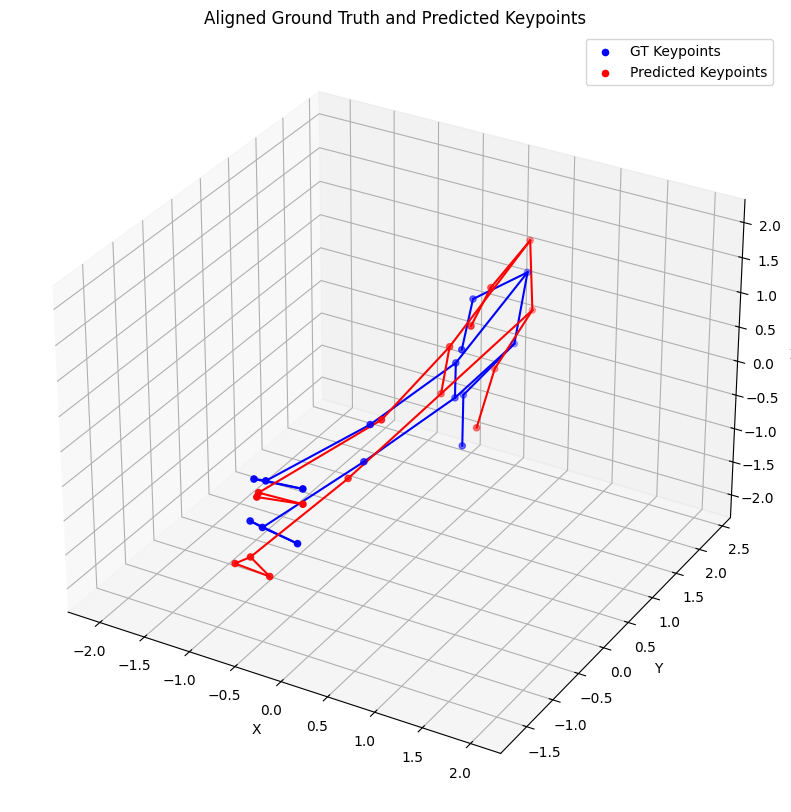

In [34]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load the dataset
file_path = 'results/1.pkl'
with open(file_path, 'rb') as file:
    data = pickle.load(file)

# Convert the keypoints dictionaries into numpy arrays
gt_points = np.array(list(data['gt'].values()))
pred_points = np.array(list(data['pred'].values()))

# Center the points by subtracting the mean
gt_centered = gt_points - np.mean(gt_points, axis=0)
pred_centered = pred_points - np.mean(pred_points, axis=0)

# Scale the points to have the same variance
gt_scaled = gt_centered / np.std(gt_centered)
pred_scaled = pred_centered / np.std(pred_centered)

# Compute the covariance matrix
cov_matrix = np.dot(pred_scaled.T, gt_scaled)

# Singular Value Decomposition
U, S, Vt = np.linalg.svd(cov_matrix)

# Compute the rotation matrix
R = np.dot(Vt.T, U.T)

# Apply the rotation to the predicted points
pred_aligned = np.dot(pred_scaled, R)

# Define the connections
connections = [(0, 1), (0, 2), (1, 3), (2, 4), (3, 5), (6, 7), (0, 6),
               (1, 7), (6, 8), (7, 9), (8, 10), (9, 11), (10, 12),
               (11, 13), (10, 14), (11, 15), (12, 14), (13, 15)]

# Create an interactive 3D plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot GT keypoints
ax.scatter(gt_scaled[:, 0], gt_scaled[:, 1], gt_scaled[:, 2], color='blue', label='GT Keypoints')
for start, end in connections:
    ax.plot([gt_scaled[start, 0], gt_scaled[end, 0]], [gt_scaled[start, 1], gt_scaled[end, 1]], [gt_scaled[start, 2], gt_scaled[end, 2]], color='blue')

# Plot aligned predicted keypoints
ax.scatter(pred_aligned[:, 0], pred_aligned[:, 1], pred_aligned[:, 2], color='red', label='Predicted Keypoints')
for start, end in connections:
    ax.plot([pred_aligned[start, 0], pred_aligned[end, 0]], [pred_aligned[start, 1], pred_aligned[end, 1]], [pred_aligned[start, 2], pred_aligned[end, 2]], color='red')

# Set equal scaling
max_range = np.array([gt_scaled[:, 0].max() - gt_scaled[:, 0].min(), 
                      gt_scaled[:, 1].max() - gt_scaled[:, 1].min(), 
                      gt_scaled[:, 2].max() - gt_scaled[:, 2].min()]).max() / 2.0

mid_x = (gt_scaled[:, 0].max() + gt_scaled[:, 0].min()) * 0.5
mid_y = (gt_scaled[:, 1].max() + gt_scaled[:, 1].min()) * 0.5
mid_z = (gt_scaled[:, 2].max() + gt_scaled[:, 2].min()) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

ax.set_title('Aligned Ground Truth and Predicted Keypoints')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()

plt.show()


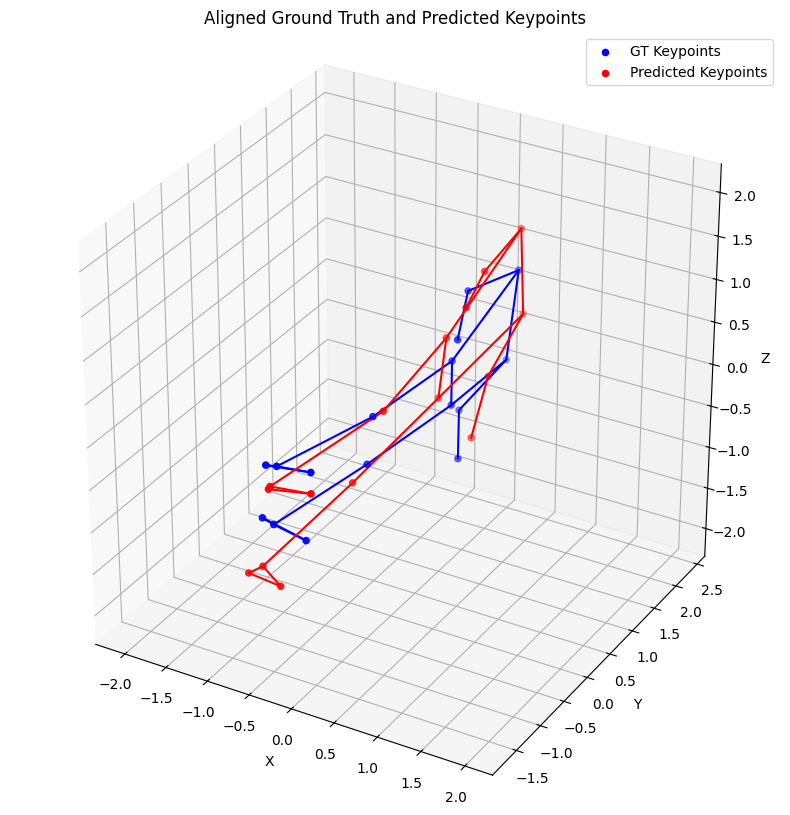

In [36]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load the dataset
file_path = 'results/1.pkl'
with open(file_path, 'rb') as file:
    data = pickle.load(file)

# Convert the keypoints dictionaries into numpy arrays
gt_points = np.array(list(data['gt'].values()))
pred_points = np.array(list(data['pred'].values()))

# Center the points by subtracting the mean
gt_centered = gt_points - np.mean(gt_points, axis=0)
pred_centered = pred_points - np.mean(pred_points, axis=0)

# Scale the points to have the same variance
gt_scaled = gt_centered / np.std(gt_centered)
pred_scaled = pred_centered / np.std(pred_centered)

# Compute the covariance matrix
cov_matrix = np.dot(pred_scaled.T, gt_scaled)

# Singular Value Decomposition
U, S, Vt = np.linalg.svd(cov_matrix)

# Compute the rotation matrix
R = np.dot(Vt.T, U.T)

# Apply the rotation to the predicted points
pred_aligned = np.dot(pred_scaled, R)

# Define the connections
connections = [(0, 1), (0, 2), (1, 3), (2, 4), (3, 5), (6, 7), (0, 6),
               (1, 7), (6, 8), (7, 9), (8, 10), (9, 11), (10, 12),
               (11, 13), (10, 14), (11, 15), (12, 14), (13, 15)]

# Create an interactive 3D plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot GT keypoints
ax.scatter(gt_scaled[:, 0], gt_scaled[:, 1], gt_scaled[:, 2], color='blue', label='GT Keypoints')
for start, end in connections:
    ax.plot([gt_scaled[start, 0], gt_scaled[end, 0]], [gt_scaled[start, 1], gt_scaled[end, 1]], [gt_scaled[start, 2], gt_scaled[end, 2]], color='blue')

# Plot aligned predicted keypoints
ax.scatter(pred_aligned[:, 0], pred_aligned[:, 1], pred_aligned[:, 2], color='red', label='Predicted Keypoints')
for start, end in connections:
    ax.plot([pred_aligned[start, 0], pred_aligned[end, 0]], [pred_aligned[start, 1], pred_aligned[end, 1]], [pred_aligned[start, 2], pred_aligned[end, 2]], color='red')

# Set equal scaling
max_range = np.array([gt_scaled[:, 0].max() - gt_scaled[:, 0].min(), 
                      gt_scaled[:, 1].max() - gt_scaled[:, 1].min(), 
                      gt_scaled[:, 2].max() - gt_scaled[:, 2].min()]).max() / 2.0

mid_x = (gt_scaled[:, 0].max() + gt_scaled[:, 0].min()) * 0.5
mid_y = (gt_scaled[:, 1].max() + gt_scaled[:, 1].min()) * 0.5
mid_z = (gt_scaled[:, 2].max() + gt_scaled[:, 2].min()) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

# Set the aspect ratio to be equal
ax.set_box_aspect([1, 1, 1])  # Aspect ratio is 1:1:1

ax.set_title('Aligned Ground Truth and Predicted Keypoints')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()

plt.show()


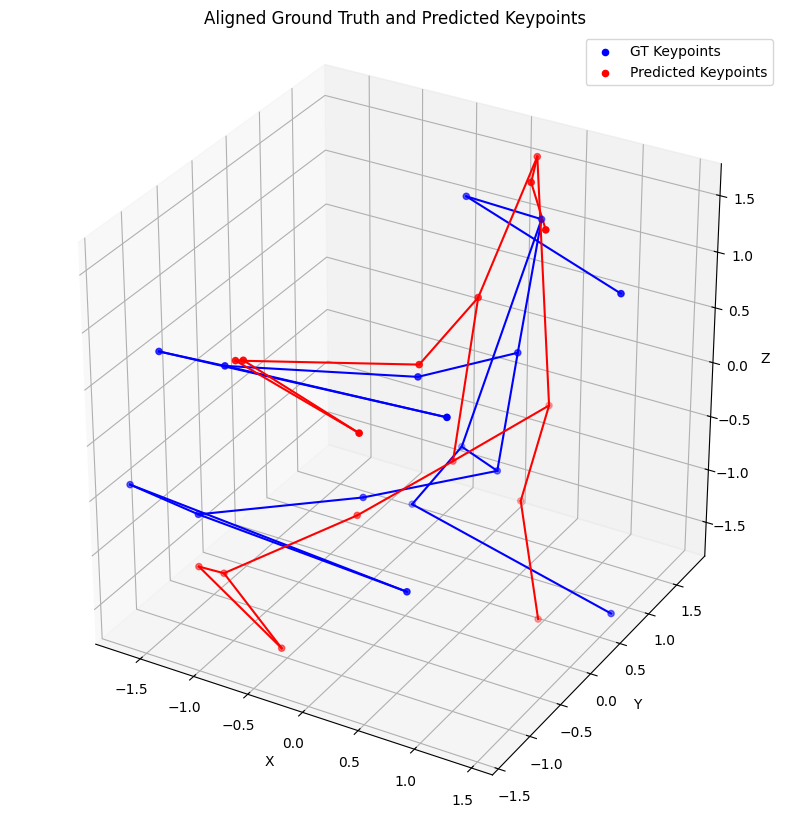

In [37]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load the dataset
file_path = 'results/1.pkl'
with open(file_path, 'rb') as file:
    data = pickle.load(file)

# Convert the keypoints dictionaries into numpy arrays
gt_points = np.array(list(data['gt'].values()))
pred_points = np.array(list(data['pred'].values()))

# Center the points by subtracting the mean
gt_centered = gt_points - np.mean(gt_points, axis=0)
pred_centered = pred_points - np.mean(pred_points, axis=0)

# Scale the points to have the same variance
gt_scaled = gt_centered / np.std(gt_centered, axis=0)
pred_scaled = pred_centered / np.std(pred_centered, axis=0)

# Compute the covariance matrix
cov_matrix = np.dot(pred_scaled.T, gt_scaled)

# Singular Value Decomposition
U, S, Vt = np.linalg.svd(cov_matrix)

# Compute the rotation matrix
R = np.dot(Vt.T, U.T)

# Apply the rotation to the predicted points
pred_aligned = np.dot(pred_scaled, R)

# Define the connections
connections = [(0, 1), (0, 2), (1, 3), (2, 4), (3, 5), (6, 7), (0, 6),
               (1, 7), (6, 8), (7, 9), (8, 10), (9, 11), (10, 12),
               (11, 13), (10, 14), (11, 15), (12, 14), (13, 15)]

# Create an interactive 3D plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot GT keypoints
ax.scatter(gt_scaled[:, 0], gt_scaled[:, 1], gt_scaled[:, 2], color='blue', label='GT Keypoints')
for start, end in connections:
    ax.plot([gt_scaled[start, 0], gt_scaled[end, 0]], [gt_scaled[start, 1], gt_scaled[end, 1]], [gt_scaled[start, 2], gt_scaled[end, 2]], color='blue')

# Plot aligned predicted keypoints
ax.scatter(pred_aligned[:, 0], pred_aligned[:, 1], pred_aligned[:, 2], color='red', label='Predicted Keypoints')
for start, end in connections:
    ax.plot([pred_aligned[start, 0], pred_aligned[end, 0]], [pred_aligned[start, 1], pred_aligned[end, 1]], [pred_aligned[start, 2], pred_aligned[end, 2]], color='red')

# Set equal scaling
max_range = np.array([gt_scaled[:, 0].max() - gt_scaled[:, 0].min(), 
                      gt_scaled[:, 1].max() - gt_scaled[:, 1].min(), 
                      gt_scaled[:, 2].max() - gt_scaled[:, 2].min()]).max() / 2.0

mid_x = (gt_scaled[:, 0].max() + gt_scaled[:, 0].min()) * 0.5
mid_y = (gt_scaled[:, 1].max() + gt_scaled[:, 1].min()) * 0.5
mid_z = (gt_scaled[:, 2].max() + gt_scaled[:, 2].min()) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

# Set the aspect ratio to be equal
ax.set_box_aspect([1, 1, 1])  # Aspect ratio is 1:1:1

ax.set_title('Aligned Ground Truth and Predicted Keypoints')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()

plt.show()


In [40]:
import pickle
import numpy as np
from scipy.spatial import procrustes
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load the dataset
file_path = 'results/1.pkl'
with open(file_path, 'rb') as file:
    data = pickle.load(file)

# Convert the keypoints dictionaries into numpy arrays for Procrustes analysis
gt_points = np.array(list(data['gt'].values()))
pred_points = np.array(list(data['pred'].values()))

# Check the original scale
scale_gt = np.max(gt_points, axis=0) - np.min(gt_points, axis=0)
scale_pred = np.max(pred_points, axis=0) - np.min(pred_points, axis=0)

print("Original GT Scale:", scale_gt)
print("Original Pred Scale:", scale_pred)

# Perform Procrustes analysis for 3D coordinates
mtx1_3d, mtx2_3d, disparity_3d = procrustes(gt_points, pred_points)

# Optional: Manual scaling adjustment if needed
manual_scale = scale_gt / scale_pred
mtx2_3d = mtx2_3d * manual_scale

# Define the connections
connections = [(0, 1), (0, 2), (1, 3), (2, 4), (3, 5), (6, 7), (0, 6),
               (1, 7), (6, 8), (7, 9), (8, 10), (9, 11), (10, 12),
               (11, 13), (10, 14), (11, 15), (12, 14), (13, 15)]

# Create an interactive 3D plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot GT keypoints
ax.scatter(mtx1_3d[:, 0], mtx1_3d[:, 1], mtx1_3d[:, 2], color='blue', label='GT Keypoints')
for start, end in connections:
    ax.plot([mtx1_3d[start, 0], mtx1_3d[end, 0]], [mtx1_3d[start, 1], mtx1_3d[end, 1]], [mtx1_3d[start, 2], mtx1_3d[end, 2]], color='blue')

# Plot predicted keypoints
ax.scatter(mtx2_3d[:, 0], mtx2_3d[:, 1], mtx2_3d[:, 2], color='red', label='Predicted Keypoints')
for start, end in connections:
    ax.plot([mtx2_3d[start, 0], mtx2_3d[end, 0]], [mtx2_3d[start, 1], mtx2_3d[end, 1]], [mtx2_3d[start, 2], mtx2_3d[end, 2]], color='red')

ax.set_title('Aligned Ground Truth and Predicted Keypoints')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()

plt.show()


Original GT Scale: [ 181.7835   1149.316201  388.59252 ]
Original Pred Scale: [0.34764822 1.32437316 0.5903621 ]


<IPython.core.display.Javascript object>

In [48]:
import pickle
import numpy as np
from scipy.spatial import procrustes
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Enable interactive mode
%matplotlib notebook

# Load the dataset
file_path = 'results/6.pkl'
with open(file_path, 'rb') as file:
    data = pickle.load(file)

# Convert the keypoints dictionaries into numpy arrays for Procrustes analysis
gt_points = np.array(list(data['gt'].values()))
pred_points = np.array(list(data['pred'].values()))

# Check the original scale
scale_gt = np.max(gt_points, axis=0) - np.min(gt_points, axis=0)
scale_pred = np.max(pred_points, axis=0) - np.min(pred_points, axis=0)

print("Original GT Scale:", scale_gt)
print("Original Pred Scale:", scale_pred)

# Perform Procrustes analysis for 3D coordinates
mtx1_3d, mtx2_3d, disparity_3d = procrustes(gt_points, pred_points)

# Define the connections
connections = [(0, 1), (0, 2), (1, 3), (2, 4), (3, 5), (6, 7), (0, 6),
               (1, 7), (6, 8), (7, 9), (8, 10), (9, 11), (10, 12),
               (11, 13), (10, 14), (11, 15), (12, 14), (13, 15)]

# Calculate the global min and max for setting equal axis ranges
all_points = np.vstack((mtx1_3d, mtx2_3d))
min_vals = np.min(all_points, axis=0)
max_vals = np.max(all_points, axis=0)

# Determine the range to ensure equal axis scaling
range_vals = np.max(max_vals - min_vals)
mid_vals = (max_vals + min_vals) / 2

# Create an interactive 3D plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot GT keypoints
ax.scatter(mtx1_3d[:, 0], mtx1_3d[:, 1], mtx1_3d[:, 2], color='blue', label='GT Keypoints')
for start, end in connections:
    ax.plot([mtx1_3d[start, 0], mtx1_3d[end, 0]], [mtx1_3d[start, 1], mtx1_3d[end, 1]], [mtx1_3d[start, 2], mtx1_3d[end, 2]], color='blue')

# Plot predicted keypoints
ax.scatter(mtx2_3d[:, 0], mtx2_3d[:, 1], mtx2_3d[:, 2], color='red', label='Predicted Keypoints')
for start, end in connections:
    ax.plot([mtx2_3d[start, 0], mtx2_3d[end, 0]], [mtx2_3d[start, 1], mtx2_3d[end, 1]], [mtx2_3d[start, 2], mtx2_3d[end, 2]], color='red')

# Set the same range for all axes
ax.set_xlim(mid_vals[0] - range_vals / 2, mid_vals[0] + range_vals / 2)
ax.set_ylim(mid_vals[1] - range_vals / 2, mid_vals[1] + range_vals / 2)
ax.set_zlim(mid_vals[2] - range_vals / 2, mid_vals[2] + range_vals / 2)

ax.set_title('Aligned Ground Truth and Predicted Keypoints')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()

plt.show()


Original GT Scale: [ 332.27472  1145.231364  538.6101  ]
Original Pred Scale: [0.57868119 1.31361178 0.50430575]


<IPython.core.display.Javascript object>